In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmocean as cmo


ds = xr.open_dataset("hydro_FlocOn.nc", decode_times=False)
print(ds)

ds2 = xr.open_dataset("hydro_FlocOff.nc", decode_times=False)

nt = len(ds.time) - 1


<xarray.Dataset> Size: 17MB
Dimensions:  (time: 1081, Ds: 30, z: 50)
Coordinates:
  * time     (time) float32 4kB 1.0 2.0 3.0 4.0 ... 1.079e+03 1.08e+03 1.081e+03
  * Ds       (Ds) float32 120B 1e-06 1.221e-06 1.492e-06 ... 0.0002702 0.00033
  * z        (z) float32 200B 9.9 9.7 9.5 9.3 9.1 8.9 ... 0.9 0.7 0.5 0.3 0.1
Data variables:
    ssc      (time, Ds, z) float64 13MB ...
    U        (time, z) float64 432kB ...
    Kq       (time, z) float64 432kB ...
    Nu       (time, z) float64 432kB ...
    C        (time, z) float64 432kB ...
    Kz       (time, z) float64 432kB ...
    L        (time, z) float64 432kB ...
    Q2       (time, z) float64 432kB ...
    Q2L      (time, z) float64 432kB ...
    N_BV2    (time, z) float64 432kB ...
Attributes:
    title:    testing


<>:28: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:28: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_644962/248516422.py:28: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))
/tmp/ipykernel_644962/248516422.py:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the f

Text(0, 0.5, 'Depth (m)')

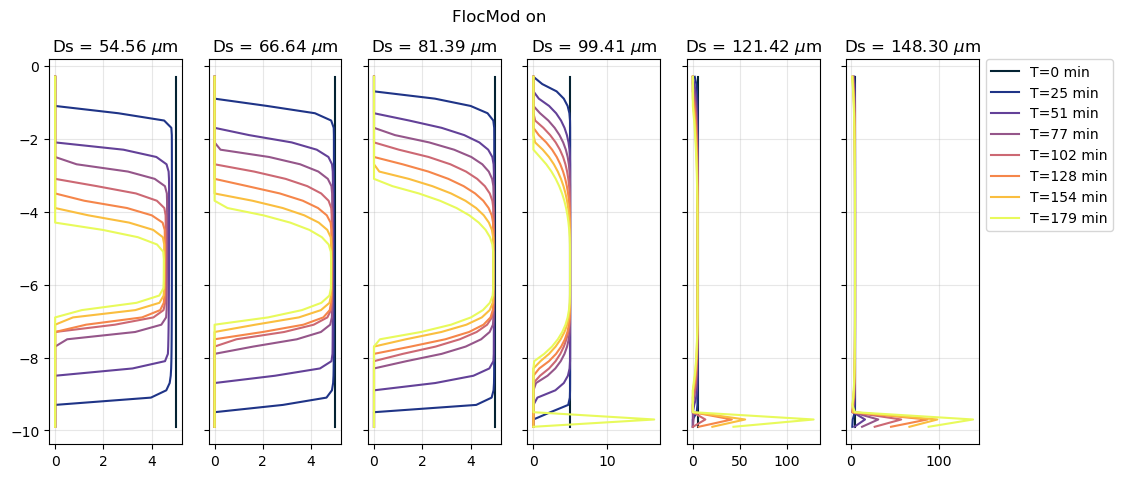

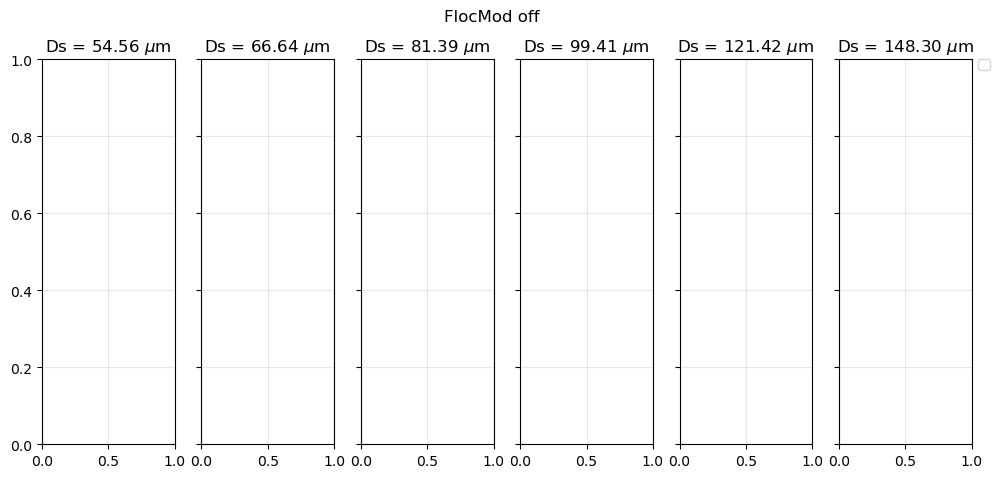

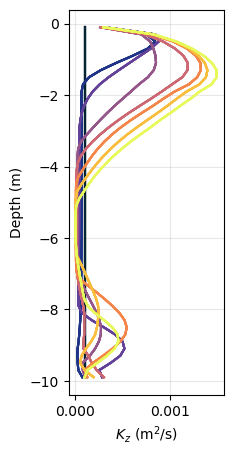

In [2]:

fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(12, 5), sharex=False, sharey=True)
axs = axs.flatten()
plt.suptitle("FlocMod on")


fig2, axs2 = plt.subplots(nrows=1, ncols=6, figsize=(12, 5), sharex=False, sharey=True)
plt.suptitle("FlocMod off")

fig3 = plt.figure(figsize=(2, 5))
ax3 = plt.gca() 

ST = 20 
for t in range(0, nt, nt//7):
    for i, d in enumerate(range(ST,ST+6,1)):
        # i = i*4
        color = cmo.cm.thermal(t/nt) 
        # var = ds.Kz.isel(time=t)
        var = ds.Kq.isel(time=t)
        ax3.plot(var, -ds.z, color=color, label="T=%d min" % (t*10/60))


        var = ds.ssc.isel(time=t).isel(Ds=d)
        # print(var.values)
        h= axs[i].plot(var[0:-1], -ds.z[0:-1], color=color, label="T=%d min" % (t*10/60))
        axs[i].grid(alpha=0.3)
        axs2[i].grid(alpha=0.3)

        axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))
        axs2[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))


axs[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
axs2[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )


ax3.set_xlabel("$K_z$ (m$^2$/s)")
ax3.grid(alpha=0.3)
ax3.set_ylabel("Depth (m)")

<xarray.DataArray 'ssc' (Ds: 30)> Size: 240B
array([  5.,   5.,   5.,   5.,   5.,   5.,   5.,   5.,   5., 350., 350., 350.,
       350., 350., 350., 350., 350., 350., 350., 350.,   5.,   5.,   5.,   5.,
         5.,   5.,   5.,   5.,   5.,   5.])
Coordinates:
  * Ds       (Ds) float32 120B 1e-06 1.221e-06 1.492e-06 ... 0.0002702 0.00033
    z        float32 4B 9.9
    time     float32 4B 1.0
Attributes:
    units:      parts/m3
    long_name:  suspended sediment concentration
<xarray.DataArray 'ssc' (Ds: 30)> Size: 240B
array([  5.,   5.,   5.,   5.,   5.,   5.,   5.,   5.,   5., 350., 350., 350.,
       350., 350., 350., 350., 350., 350., 350., 350.,   5.,   5.,   5.,   5.,
         5.,   5.,   5.,   5.,   5.,   5.])
Coordinates:
  * Ds       (Ds) float32 120B 1e-06 1.221e-06 1.492e-06 ... 0.0002702 0.00033
    z        float32 4B 6.9
    time     float32 4B 1.0
Attributes:
    units:      parts/m3
    long_name:  suspended sediment concentration
<xarray.DataArray 'ssc' (Ds: 30)> Size

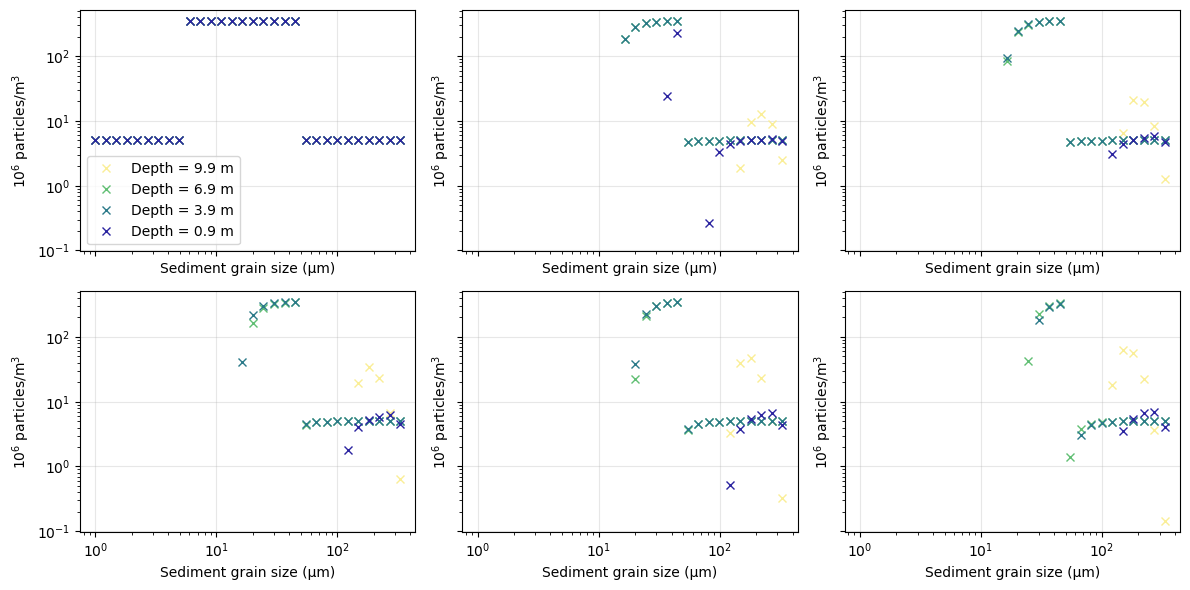

In [3]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
axs = axs.flatten()

z = ds.z.values
for i,t in enumerate(range(0, nt, nt//6)):
    # var = ds.Kz.isel(time=12)

    for dep in range(0, 50, 15):
        var = ds.ssc.isel(z=dep).isel(time=t)
        axs[i].plot(ds.Ds.values*1e6, var, 'x', color=cmo.cm.haline(z[dep]/10), label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
    # axs[i].plot(ds.ssc.isel(time=400).isel(Ds=i), ds.z)
        print(var)
# print(var.values) 
    axs[i].set_xscale('log')
    axs[i].grid(alpha=0.3)
    axs[i].set_yscale('log')

    axs[i].set_xlabel("Sediment grain size (µm)")
    axs[i].set_ylabel("10$^6$ particles/m$^3$")
axs[0].legend()
plt.tight_layout()

/tmp/ipykernel_100344/3506766825.py:23: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs.set_ylim(0,)


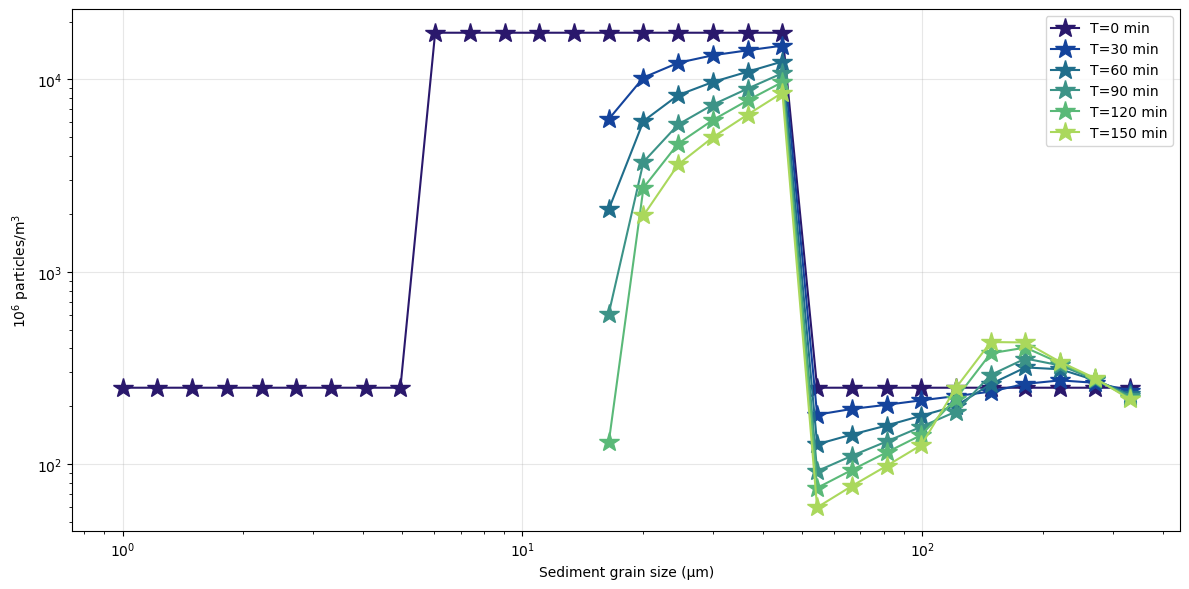

In [10]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 6), sharex=True, sharey=True)

z = ds.z.values
for i,t in enumerate(range(0, nt, nt//6)):
    # var = ds.Kz.isel(time=12)

    label="T=%d min" % (t*10/60)
    # print(i, t, time)
    
    var = ds.ssc.isel(time=t).sum(dim='z')
    var[var<2] = np.nan
    axs.plot(ds.Ds.values*1e6, var, '-*', color=cmo.cm.haline(t/nt), markersize=15, label=label) #,color=cmo.cm.thermal(t/nt))
# axs[i].plot(ds.ssc.isel(time=400).isel(Ds=i), ds.z)
    # print(var)
# print(var.values) 
    axs.set_xscale('log')
    axs.grid(alpha=0.3)
    axs.set_yscale('log')

    axs.set_xlabel("Sediment grain size (µm)")
    axs.set_ylabel("10$^6$ particles/m$^3$")
axs.legend()
axs.set_ylim(0,)
plt.tight_layout()

(30,) (1081, 30)
(30,) (1081, 30)
(30,) (1081, 30)
(30,) (1081, 30)


(0.008333333767950535, 2.9972221851348877)

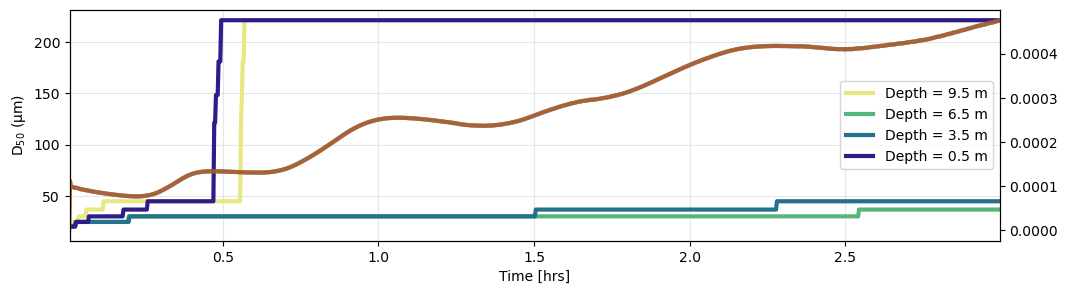

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 3), sharex=True, sharey=True)
ax2 = ax.twinx()

z = ds.z.values

for dep in range(2, 50, 15):
    hours = ds.time.values / 360
    var = ds.ssc.isel(z=dep) # .isel(time=t)
    print(ds.Ds.values.shape, var.values.shape)
    # broadcast Ds to match var shape
    Ds = np.broadcast_to(ds.Ds.values, var.values.shape)
    weights = var.values + 1e-3
    mean_d = np.percentile(Ds, axis=1, q=50, weights=weights, method="inverted_cdf")
    ax.plot(hours, mean_d*1e6, color=cmo.cm.haline(z[dep]/10), linewidth=3, label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
    kz = ds.Kq.mean(dim="z")
    ax2.plot(hours, kz, linewidth=3, alpha = 0.5)

# ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend()
# ax.set_xlim(0, 5)
ax.set_xlabel("Time [hrs]")
ax.set_ylabel("D$_{50}$ (µm)")
ax.set_xlim(hours[2], hours[-3])
# axs[i].set_ylabel("10$^6$ particles/m$^3$")
# axs[0].legend()
# plt.tight_layout()